原始图片信息:
 类型:<class 'PIL.JpegImagePlugin.JpegImageFile'>
 尺寸:(6720, 4480)
 格式:JPEG
 模式:RGB

转换后张量信息
 类型:<class 'torch.Tensor'>
 形状:torch.Size([3, 4480, 6720])
 数据类型:torch.float32
 值范围:[-1.000, 1.000]
 均值:0.445
 标准差:0.500


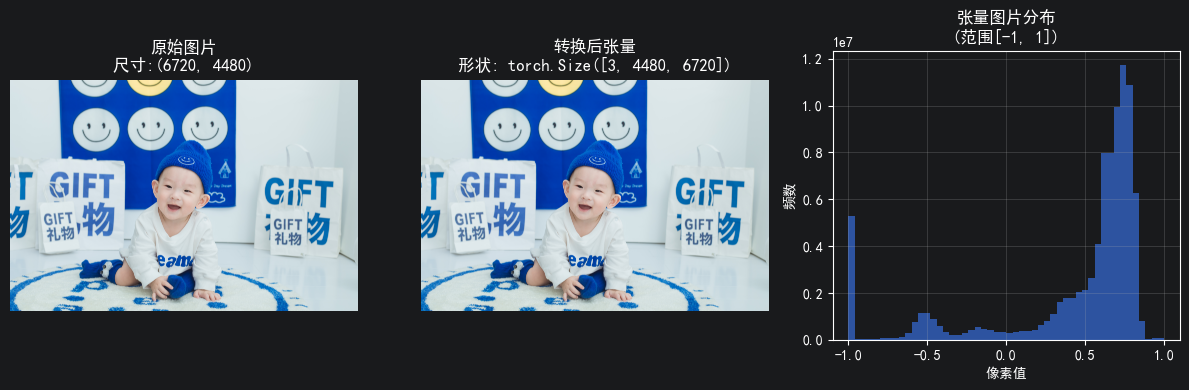

In [1]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

image_path = '../data/0Q3A0032.JPG'
img = Image.open(image_path)

print('原始图片信息:')
print(f' 类型:{type(img)}')
print(f' 尺寸:{img.size}')
print(f' 格式:{img.format}')
print(f' 模式:{img.mode}')

plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f'原始图片\n尺寸:{img.size}')
plt.axis('off')

tensor_img = transforms(img)

print(f'\n转换后张量信息')
print(f' 类型:{type(tensor_img)}')
print(f' 形状:{tensor_img.shape}')
print(f' 数据类型:{tensor_img.dtype}')
print(f' 值范围:[{tensor_img.min():.3f}, {tensor_img.max():.3f}]')
print(f' 均值:{tensor_img.mean():.3f}')
print(f' 标准差:{tensor_img.std():.3f}')

# 显示转换后的张量
# 反归一化: output = tensor * 0.5 + 0.5
display_img = tensor_img * 0.5 + 0.5
display_img = display_img.clamp(0, 1)

# 转换为numpy并调整维度顺序
np_img = display_img.numpy()
np_img = np.transpose(np_img, (1, 2, 0))

plt.subplot(1, 3, 2)
plt.imshow(np_img)
plt.title(f'转换后张量\n形状: {tensor_img.shape}')
plt.axis('off')

plt.subplot(1,3,3)
plt.hist(tensor_img.numpy().flatten(), bins=50, alpha=0.7)
plt.title('张量图片分布\n(范围[-1, 1])')
plt.xlabel('像素值')
plt.ylabel('频数')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()